In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from vol_models import get_model
from objectives import get_objective
from calibrator import calibrate_snapshot, summary
from vol_plots  import plot_all, plot_compare

def clean_df(path: str):
    """Cleans the market microstructure data

    Args:
        path (str): path of the file we want to use as the df 
    returns: pd.DataFrame
    """
    df = pd.read_csv(path)
    put_boundary_mask = (df['underlying_price']*df['bid_price']<df['strike']) & (df['option_type']=='P')
    call_boundary_mask = (df['option_type']=='C') & (df['bid_price']<1)
    
    clean_df = df[put_boundary_mask | call_boundary_mask].copy()
    
    #Timestamp standardisation
    ts = clean_df.creation_timestamp_x[0]
    clean_df['creation_timestamp_x'] = ts
    clean_df['creation_timestamp_x'] = clean_df['creation_timestamp_x'] #2h, paris = gmt +2
    clean_df['expiration_timestamp'] = pd.to_datetime(df['expiration_timestamp'], format='%d%b%y')+pd.Timedelta(hours=8)
    clean_df['expiration_timestamp_ms'] = clean_df['expiration_timestamp'].astype('int64') / 10**6
    clean_df['file_timestamp'] = pd.to_datetime(clean_df['creation_timestamp_x'], unit='ms').dt.strftime('%Y-%m-%d %H:%M')

    #Features
    clean_df['mark_iv']= clean_df['mark_iv']/100
    clean_df['t'] = (clean_df['expiration_timestamp_ms']-clean_df['creation_timestamp_x'])/(3.6e6*24*365)
    clean_df['k'] = np.log(clean_df['strike']/clean_df['underlying_price'])
    clean_df['w'] = clean_df['mark_iv']**2 * clean_df['t'] 

    return clean_df



df = clean_df('/Users/macbookair/Internship Natixis/data/btc_option_data_2026-05-27_13h43m.csv')
snapshot = df[df.file_timestamp == df.file_timestamp.unique()[-1]].copy()

In [23]:
import glob
from pathlib import Path

# Get all CSV files from data/ folder
csv_files = sorted(glob.glob('data/*.csv'))

# Load and clean all CSV files
global_df = pd.concat([clean_df(file) for file in csv_files], ignore_index=True)

# Save to parquet
global_df.to_parquet('data/min_options_data.parquet')

In [ ]:
from vol_models import get_model
from calibrator import calibrate_snapshot
from objectives import get_objective
from calibrator import calibrate_global_essvi
from vol_models import eSSVI
# or compare directly against ssvi:
from calibrator import compare
snapshot = snapshot[snapshot.volume>0]
obj = get_objective('iv_rmse')
r_svi  = calibrate_snapshot(snapshot, model=get_model("svi"), objective=obj, verbose=False)
r_ssvi  = calibrate_snapshot(snapshot, model=get_model("ssvi"), objective=obj, verbose=False)
theta_max = snapshot.groupby("t")["w"].mean().max()
model_essvi = eSSVI(theta_max=theta_max)
r_essvi = calibrate_global_essvi(snapshot, model=model_essvi, objective=obj, verbose=False)
compare(r_svi, r_ssvi, r_essvi)


Model     : eSSVI (global)
Objective : obj_iv_rmse
Slices    : 11  |  Params: 16 total

  rho_0=1.000  rho_m=-0.322  a=0.009
  eta=0.987  gamma=0.469

  T=0.0023  theta=0.00024  rho=-0.243  iv_rmse=0.0131
  T=0.0051  theta=0.00070  rho=-0.256  iv_rmse=0.0539
  T=0.0078  theta=0.00081  rho=-0.258  iv_rmse=0.0079
  T=0.0105  theta=0.00094  rho=-0.259  iv_rmse=0.0044
  T=0.0242  theta=0.00249  rho=-0.271  iv_rmse=0.0063
  T=0.0434  theta=0.00471  rho=-0.278  iv_rmse=0.0064
  T=0.0818  theta=0.01071  rho=-0.288  iv_rmse=0.0537
  T=0.1777  theta=0.02202  rho=-0.297  iv_rmse=0.0054
  T=0.3311  theta=0.04882  rho=-0.307  iv_rmse=0.0149
  T=0.5804  theta=0.10158  rho=-0.316  iv_rmse=0.0087
  T=0.8297  theta=0.15340  rho=-0.321  iv_rmse=0.0075
           objective   iv_rmse  iv_rrmse  price_rmse    w_rmse
model                                                         
Raw SVI  obj_iv_rmse  0.008259  0.014742    0.000117  0.000351
SSVI     obj_iv_rmse  0.013572  0.027751    0.000545  0.001637
eS

,objective,iv_rmse,iv_rrmse,price_rmse,w_rmse
model,,,,,
Raw SVI,obj_iv_rmse,0.008259,0.014742,0.000117,0.000351
SSVI,obj_iv_rmse,0.013572,0.027751,0.000545,0.001637
eSSVI,obj_iv_rmse,0.016565,0.032181,0.000677,0.002395



──────────────────────────────────────────────────────────────────────
  Model     : Raw SVI
  Objective : obj_iv_rmse
──────────────────────────────────────────────────────────────────────
       T     n       iv_rmse      iv_rrmse    price_rmse        w_rmse
──────────────────────────────────────────────────────────────────────
  0.0023    19      0.003297      0.009118      0.000029      0.000006
  0.0051    51      0.070481      0.109938      0.000266      0.000585
  0.0078    29      0.002464      0.007261      0.000055      0.000013
  0.0105    11      0.001178      0.003708      0.000032      0.000008
  0.0242    32      0.002696      0.007493      0.000065      0.000048
  0.0434    25      0.000708      0.002087      0.000030      0.000021
  0.0818    41      0.003069      0.007822      0.000201      0.000216
  0.1777    58      0.001111      0.002888      0.000055      0.000153
  0.3311    53      0.003153      0.006010      0.000102      0.001140
  0.5804    46      0.001860

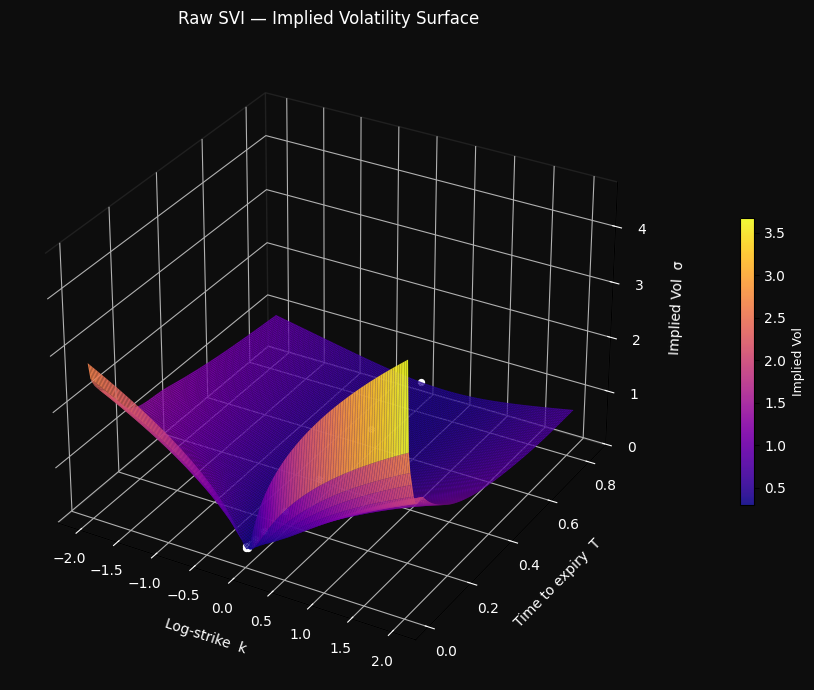

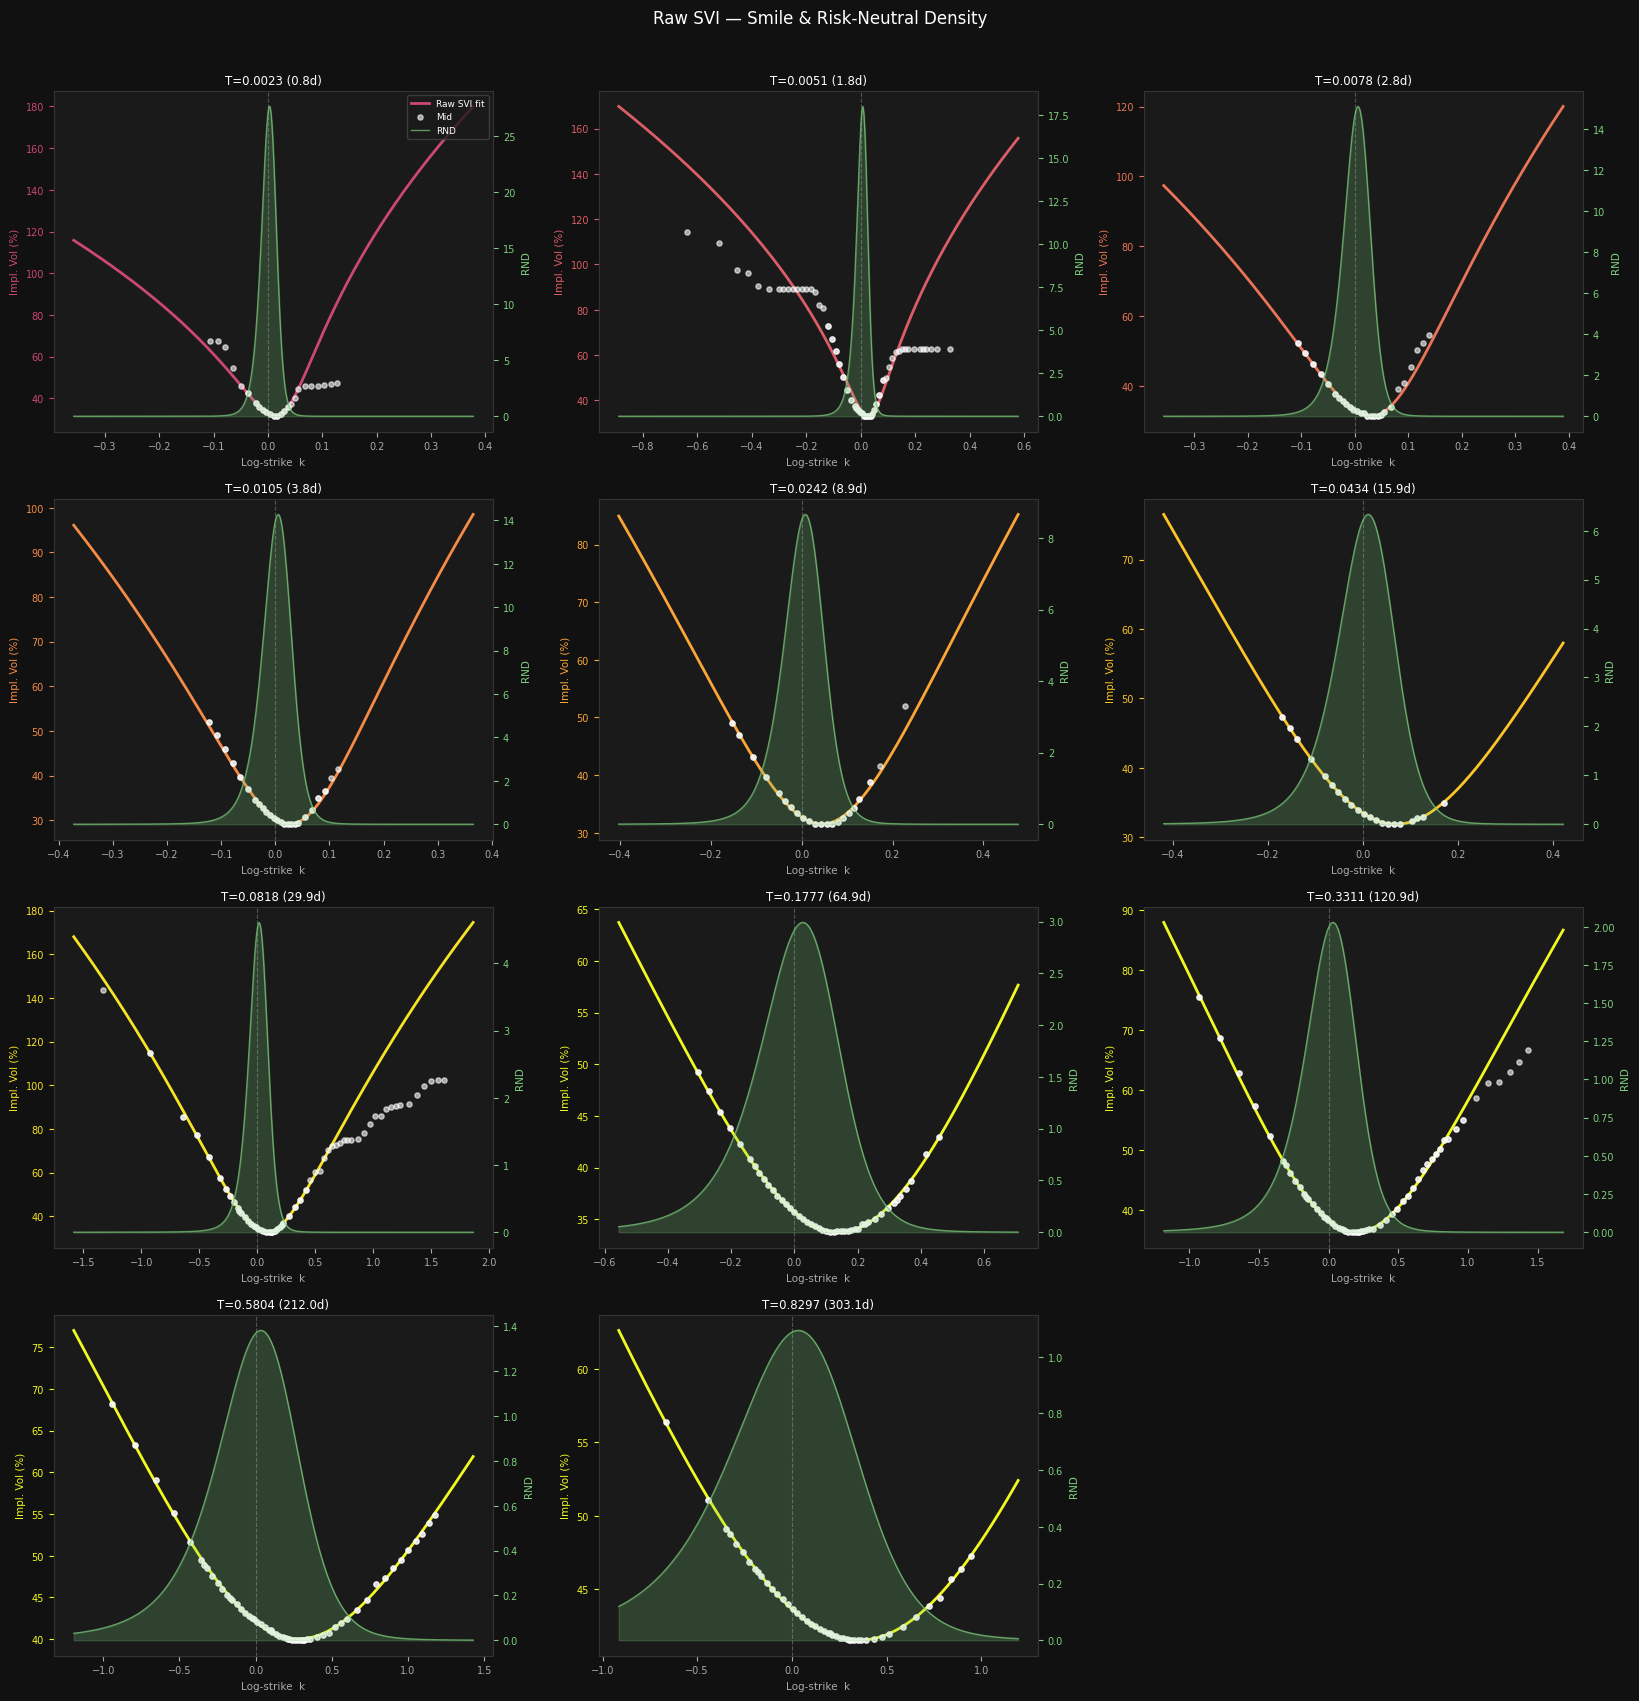

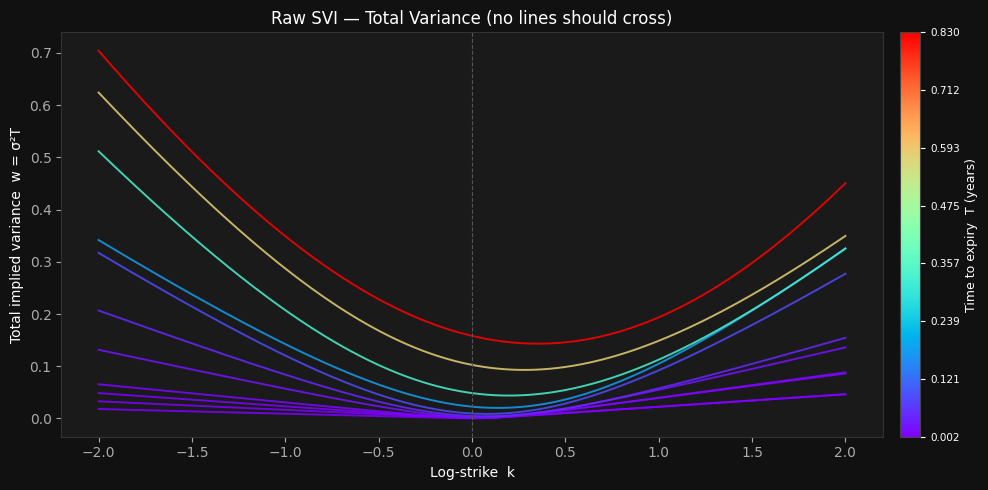

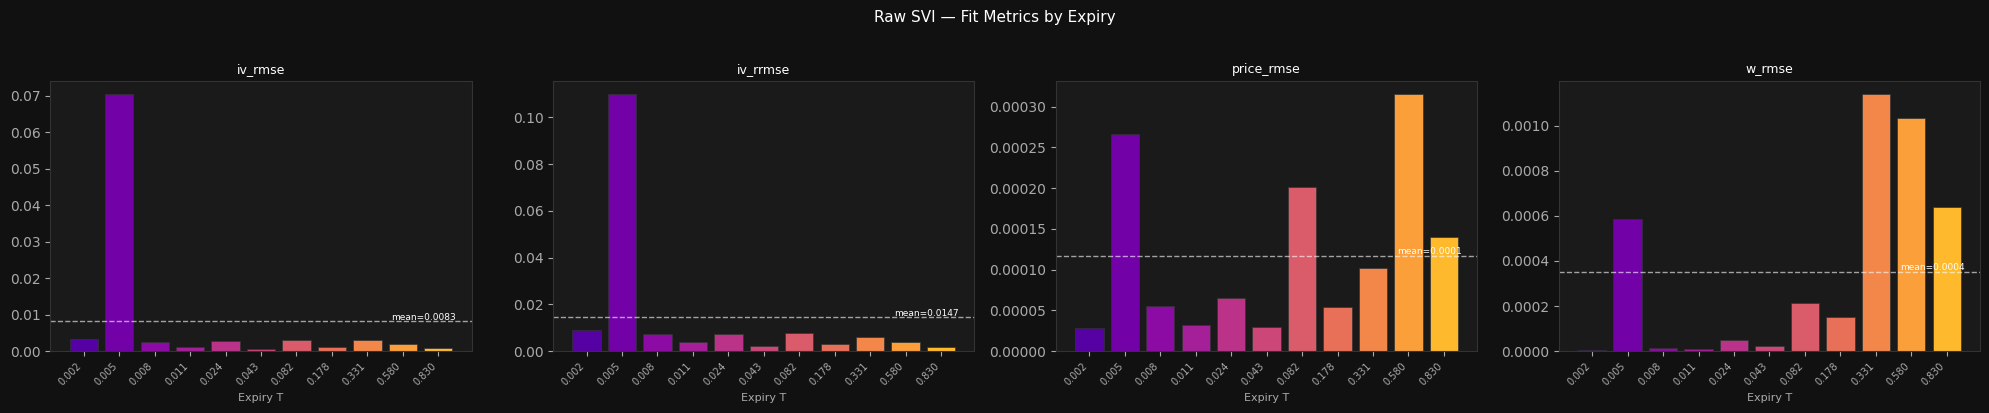

In [14]:

model = get_model('svi')
obj = get_objective('iv_rmse')

result = calibrate_snapshot(
    snapshot[snapshot.volume>0.0], 
    model=model,
    objective=obj,
    verbose=False
)

print(summary(result))



plot_all(result, df=snapshot)
plt.show()


In [4]:
# from objectives import OBJECTIVES
# import pickle
# df_full = pd.read_parquet('/Users/macbookair/Internship Natixis/data/min_options_data.parquet')
# df_t0 = df_full[df_full.file_timestamp == df_full.file_timestamp.unique()[-1]].copy()
# df_vol = df_t0[df_t0.volume>0]
# datasets = {'full':df_t0,'filtered':df_vol}

# for df_name, df in datasets.items():
#     for obj_name in OBJECTIVES.keys():
#         for model_name in ['svi','ssvi','sabr']:
#             model = get_model(model_name)
#             obj = get_objective(obj_name)

#             result = calibrate_snapshot(
#                 df, 
#                 model=model,
#                 objective=obj,
#                 verbose=False
#             )
#             filename = f'result_{model_name}_{obj_name}_{df_name}.pkl'
#             with open(filename,'wb') as f:
#                 pickle.dump(result,f)
#             print('saved',filename)

By excluding  all options that have not been traded in the last 24 hours, 

Raw
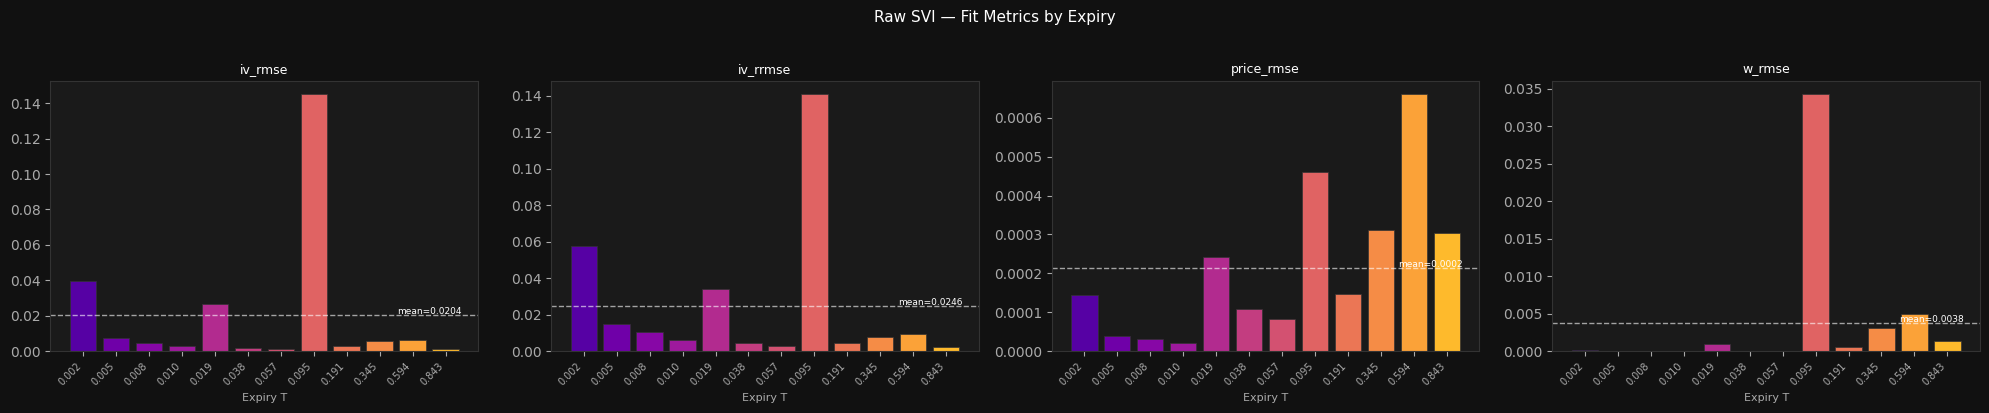

Volume-Filtered : 
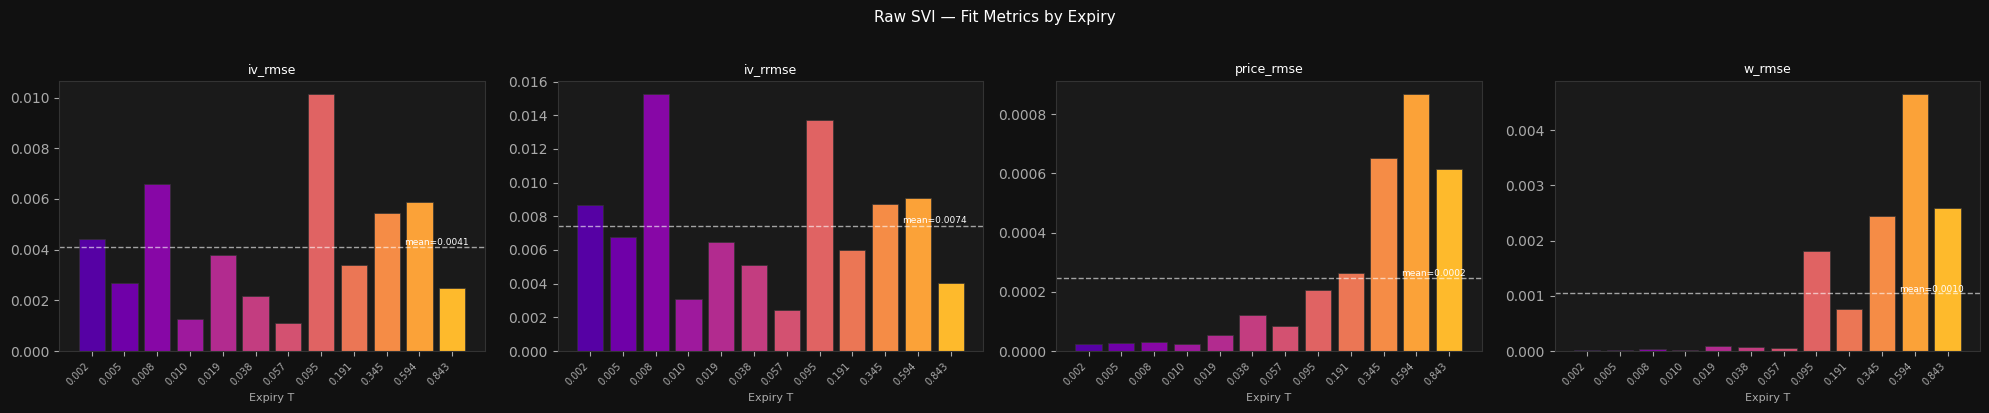

IV RMSE : Reduced by 80% \
IV RRMSE : Reduced by 70% \
Price RMSE: no change -> makes sense because iv improving by 80% on a few percent is extremely small : vega isn't large enough generally to warrant a large change \
W Rmse : Improved by 75%

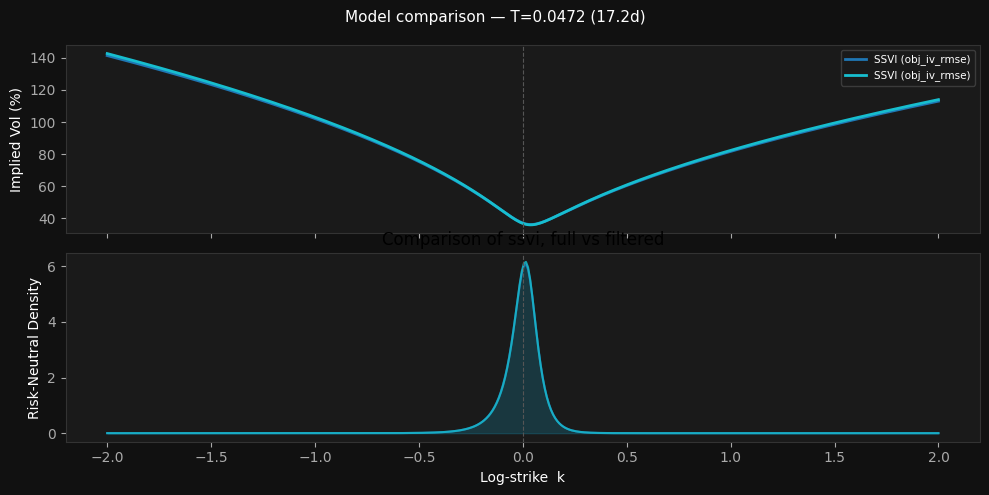

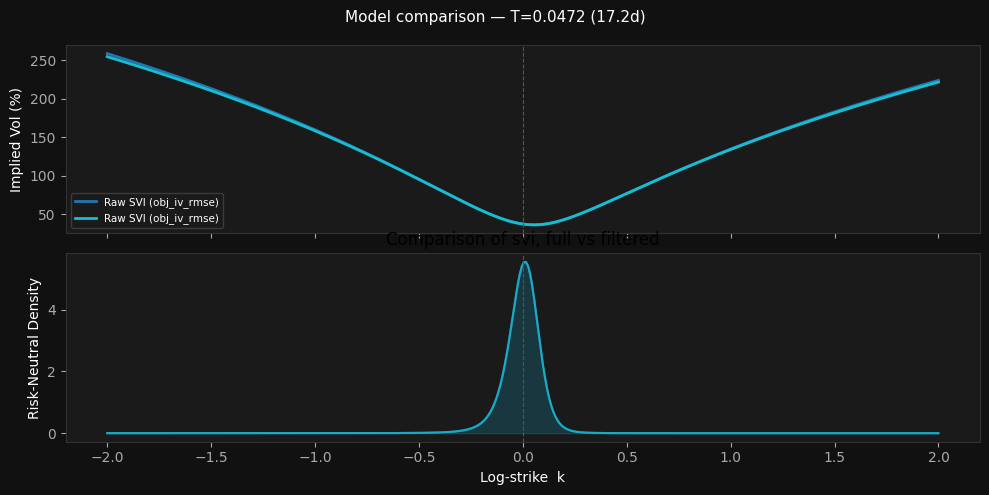

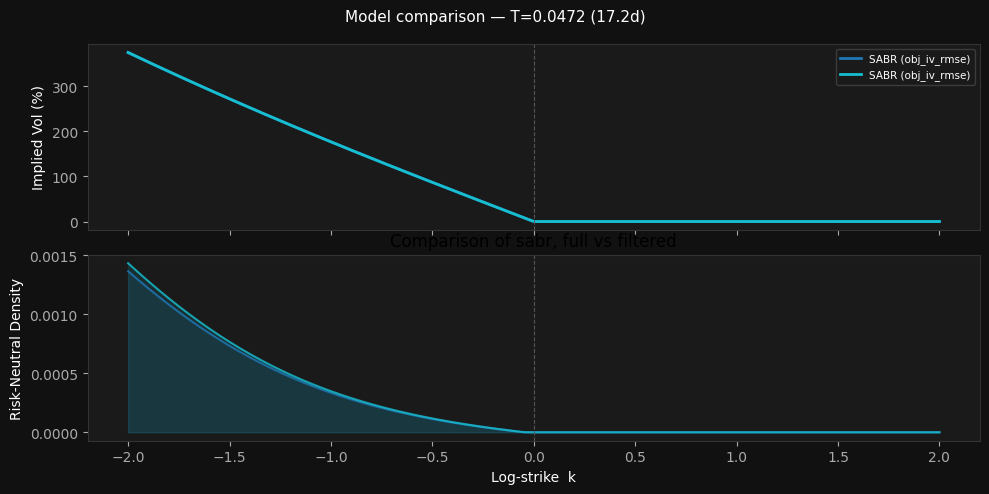

In [28]:
import pickle
snapshot = df[df.file_timestamp == df.file_timestamp.unique()[-1]].copy()
results_dict = {}
for model in ['ssvi','svi','sabr']:
    for folder in ['filtered','full']:
        with open(f'calibration_results/{folder}/result_{model}_iv_rmse_{folder}.pkl', 'rb') as f:
            results = pickle.load(f)
            results_dict[f'{folder}_{model}'] = results
    plot_compare([results_dict[f'filtered_{model}'],results_dict[f'full_{model}']], snapshot)
    plt.title(f'Comparison of {model}, full vs filtered')

In [2]:
from volatility_dataframe import implied_volatility_dataframe
df_test = df.copy()
df_test[['bid_iv','ask_iv']] = df.apply(implied_volatility_dataframe, axis=1, result_type='expand')


In [6]:
from objectives import get_objective
from volatility_dataframe import implied_volatility_dataframe

#Data is filtered for volume 
df_filtered = df[(df.volume>0) & (df.file_timestamp==df.file_timestamp.unique()[0])].copy()
df_filtered[['bid_iv','ask_iv']] = df_filtered.apply(implied_volatility_dataframe, axis=1, result_type='expand')
df_filtered.dropna(subset=['bid_iv','ask_iv'], inplace=True)
df_filtered['spread_iv'] = (df_filtered['ask_iv'] - df_filtered['bid_iv'])/2


#Data is not filtered for volume, but most missing volume is dropped through the dropna because stale prices generally violate the arbitrage conditions
df_unfiltered = df[df.file_timestamp==df.file_timestamp.unique()[0]].copy()
df_unfiltered[['bid_iv','ask_iv']] = df_unfiltered.apply(implied_volatility_dataframe, axis=1, result_type='expand')
df_unfiltered.dropna(subset=['bid_iv','ask_iv'], inplace=True)
df_unfiltered['spread_iv'] = (df_unfiltered['ask_iv'] - df_unfiltered['bid_iv'])/2

